#1 Plot Signal (ggF and VBF) with Diboson
selection : n_b_jet = 0 
            n_jet >= 2

In [1]:
import ROOT

f = ROOT.TFile("diboson.root")

f.ls()

TFile**		diboson.root	
 TFile*		diboson.root	
  KEY: TTree	AnalysisMiniTree;1	AnalysisMiniTree


/home/est3ban3/IFJ_PAN_PROJECT/MVA-Project/venv/lib/python3.14/site-packages/ROOT/__init__.py:222: UserWarning: 
This distribution of ROOT is in alpha stage. Feedback is welcome and appreciated. Feel free to reach out to the user forum for questions and general feedback at https://root-forum.cern.ch or to submit an issue at https://github.com/root-project/root/issues. Do not rely on this distribution for production purposes.

  warnings.warn(


In [2]:
tree = f.Get("AnalysisMiniTree")

tree.Print()

******************************************************************************
*Tree    :AnalysisMiniTree: AnalysisMiniTree                                       *
*Entries :   621842 : Total =       330150040 bytes  File  Size =  150222450 *
*        :          : Tree compression factor =   2.20                       *
******************************************************************************
*Br    0 :dsid      : dsid/I                                                 *
*Entries :   621842 : Total  Size=    2500441 bytes  File Size  =      26754 *
*Baskets :      124 : Basket Size=      32000 bytes  Compression=  93.36     *
*............................................................................*
*Br    1 :hhml_subChannelFlavor : hhml_subChannelFlavor/I                    *
*Entries :   621842 : Total  Size=    2502617 bytes  File Size  =     268200 *
*Baskets :      124 : Basket Size=      32000 bytes  Compression=   9.32     *
*.............................................

In [3]:
f_sig_1 =ROOT.TFile("signal_ggF.root")

f_sig_1.ls()

TFile**		signal_ggF.root	
 TFile*		signal_ggF.root	
  KEY: TTree	AnalysisMiniTree;1	AnalysisMiniTree


In [4]:
tree_sig_1 = f_sig_1.Get("AnalysisMiniTree")

tree.Print()

******************************************************************************
*Tree    :AnalysisMiniTree: AnalysisMiniTree                                       *
*Entries :   621842 : Total =       330150040 bytes  File  Size =  150222450 *
*        :          : Tree compression factor =   2.20                       *
******************************************************************************
*Br    0 :dsid      : dsid/I                                                 *
*Entries :   621842 : Total  Size=    2500441 bytes  File Size  =      26754 *
*Baskets :      124 : Basket Size=      32000 bytes  Compression=  93.36     *
*............................................................................*
*Br    1 :hhml_subChannelFlavor : hhml_subChannelFlavor/I                    *
*Entries :   621842 : Total  Size=    2502617 bytes  File Size  =     268200 *
*Baskets :      124 : Basket Size=      32000 bytes  Compression=   9.32     *
*.............................................

In [5]:
f_sig_2 = ROOT.TFile("signal_VBF.root")

f_sig_2.ls()

TFile**		signal_VBF.root	
 TFile*		signal_VBF.root	
  KEY: TTree	AnalysisMiniTree;1	AnalysisMiniTree


In [6]:
tree_sig_2 = f_sig_2.Get("AnalysisMiniTree")
tree_sig_2.Print()

******************************************************************************
*Tree    :AnalysisMiniTree: AnalysisMiniTree                                       *
*Entries :    47257 : Total =        25293543 bytes  File  Size =   11338054 *
*        :          : Tree compression factor =   2.23                       *
******************************************************************************
*Br    0 :dsid      : dsid/I                                                 *
*Entries :    47257 : Total  Size=     191492 bytes  File Size  =       3295 *
*Baskets :       21 : Basket Size=      32000 bytes  Compression=  57.90     *
*............................................................................*
*Br    1 :hhml_subChannelFlavor : hhml_subChannelFlavor/I                    *
*Entries :    47257 : Total  Size=     191917 bytes  File Size  =      21920 *
*Baskets :       21 : Basket Size=      32000 bytes  Compression=   8.72     *
*.............................................

Info in <TCanvas::Print>: png file met_sig_vs_bkg1.png has been created


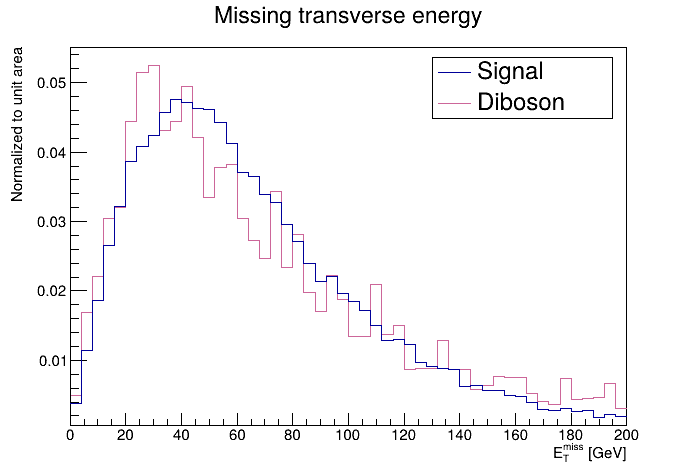

In [7]:
#combine the two signal trees
sig_chain = ROOT.TChain("AnalysisMiniTree")
sig_chain.Add("signal_ggF.root")
sig_chain.Add("signal_VBF.root")

#opens and grabs background
f_bkg = ROOT.TFile("diboson.root")
t_bkg = f_bkg.Get("AnalysisMiniTree")

#call RDataFrame as its better for cuts
df_sig = ROOT.RDataFrame(sig_chain)
df_bkg = ROOT.RDataFrame(t_bkg)

#apply cuts
df_sig = df_sig.Filter("n_b_jet == 0 && n_jet >= 2")
df_bkg = df_bkg.Filter("n_b_jet == 0 && n_jet >= 2")

#convert met_met from MeV to GeV
df_sig = df_sig.Define("met_met_GeV", "met_met / 1000.")
df_bkg = df_bkg.Define("met_met_GeV", "met_met / 1000.")

#build histo
h_sig = df_sig.Histo1D(("h_sig", "Missing transverse energy;E_{T}^{miss} [GeV];Normalized to unit area", 50, 0, 200), "met_met_GeV", "weight")
h_bkg = df_bkg.Histo1D(("h_bkg", "Missing transverse energy;E_{T}^{miss} [GeV];Normalized to unit area", 50, 0, 200), "met_met_GeV", "weight")

#fill before normalising
h_sig.GetValue()
h_bkg.GetValue()

#normalises to 1
h_sig.Scale(1.0 / h_sig.Integral())
h_bkg.Scale(1.0 / h_bkg.Integral())

c = ROOT.TCanvas()
h_bkg.SetLineColor(ROOT.kPink + 2)
h_bkg.Draw("hist")
h_sig.Draw("hist same")

ROOT.gStyle.SetOptStat(0)

leg = ROOT.TLegend(0.62, 0.75, 0.88, 0.88)
leg.AddEntry(h_sig.GetPtr(), "Signal", "l")
leg.AddEntry(h_bkg.GetPtr(), "Diboson", "l")
leg.Draw()

c.SaveAs("met_sig_vs_bkg1.png")

In [8]:
#get all branch names from the tree
all_vars = [str(name) for name in df_sig.GetColumnNames()]

#branches to skip (not sensible to histogram, e.g. IDs/flags)
skip_vars = ["dsid", "eventNumber", "weight"]

for var in all_vars:
    if var in skip_vars:
        continue

    h_sig_var = df_sig.Histo1D((f"h_sig_{var}", f"{var};{var};Normalized to unit area", 50, df_sig.Min(var).GetValue(), df_sig.Max(var).GetValue()), var, "weight")
    h_bkg_var = df_bkg.Histo1D((f"h_bkg_{var}", f"{var};{var};Normalized to unit area", 50, df_sig.Min(var).GetValue(), df_sig.Max(var).GetValue()), var, "weight")

    h_sig_var.GetValue()
    h_bkg_var.GetValue()

    if h_sig_var.Integral() == 0 or h_bkg_var.Integral() == 0:
        print(f"skipping {var}, empty histogram")
        continue

    h_sig_var.Scale(1.0 / h_sig_var.Integral())
    h_bkg_var.Scale(1.0 / h_bkg_var.Integral())

    c = ROOT.TCanvas()
    h_bkg_var.SetLineColor(ROOT.kPink + 2)
    h_bkg_var.Draw("hist")
    h_sig_var.Draw("hist same")

    leg = ROOT.TLegend(0.62, 0.75, 0.88, 0.88)
    leg.AddEntry(h_sig_var.GetPtr(), "Signal", "l")
    leg.AddEntry(h_bkg_var.GetPtr(), "Diboson", "l")
    leg.Draw()

    c.SaveAs(f"plots/{var}.png")

python ERROR: cannot open image file "plots/HT.png" for writing. Please check permissions.
Error in <TASImage::WriteImage>: error writing file plots/HT.png
python ERROR: cannot open image file "plots/HT_all.png" for writing. Please check permissions.
Error in <TASImage::WriteImage>: error writing file plots/HT_all.png
python ERROR: cannot open image file "plots/HT_jet.png" for writing. Please check permissions.
Error in <TASImage::WriteImage>: error writing file plots/HT_jet.png
python ERROR: cannot open image file "plots/HT_lep.png" for writing. Please check permissions.
Error in <TASImage::WriteImage>: error writing file plots/HT_lep.png
python ERROR: cannot open image file "plots/HT_lepMET.png" for writing. Please check permissions.
Error in <TASImage::WriteImage>: error writing file plots/HT_lepMET.png
python ERROR: cannot open image file "plots/HT_tau.png" for writing. Please check permissions.
Error in <TASImage::WriteImage>: error writing file plots/HT_tau.png
python ERROR: cann

skipping SumPt_l1j1j2, empty histogram


python ERROR: cannot open image file "plots/SumPt_t1t2.png" for writing. Please check permissions.
Error in <TASImage::WriteImage>: error writing file plots/SumPt_t1t2.png


skipping SumPt_t1t2l1, empty histogram


Error in <TAxis::TAxis::Set>: Axis limits need to be finite numbers
Error in <TAxis::TAxis::Set>: Axis limits need to be finite numbers
python ERROR: cannot open image file "plots/dR_j1j2.png" for writing. Please check permissions.
Error in <TASImage::WriteImage>: error writing file plots/dR_j1j2.png
Error in <TAxis::TAxis::Set>: Axis limits need to be finite numbers
Error in <TAxis::TAxis::Set>: Axis limits need to be finite numbers


...

skipping m_jjl1, empty histogram


Error in <TAxis::TAxis::Set>: Axis limits need to be finite numbers
Error in <TAxis::TAxis::Set>: Axis limits need to be finite numbers
Error in <TAxis::TAxis::Set>: Axis limits need to be finite numbers
python ERROR: cannot open image file "plots/m_l1j.png" for writing. Please check permissions.
Error in <TASImage::WriteImage>: error writing file plots/m_l1j.png


skipping m_jjl1t1, empty histogram
skipping m_jjt1, empty histogram


python ERROR: cannot open image file "plots/m_l1j1.png" for writing. Please check permissions.
Error in <TASImage::WriteImage>: error writing file plots/m_l1j1.png
python ERROR: cannot open image file "plots/m_l1j2.png" for writing. Please check permissions.
Error in <TASImage::WriteImage>: error writing file plots/m_l1j2.png
python ERROR: cannot open image file "plots/m_l1t.png" for writing. Please check permissions.
Error in <TASImage::WriteImage>: error writing file plots/m_l1t.png
python ERROR: cannot open image file "plots/m_l1t1.png" for writing. Please check permissions.
Error in <TASImage::WriteImage>: error writing file plots/m_l1t1.png
python ERROR: cannot open image file "plots/m_l1t2.png" for writing. Please check permissions.
Error in <TASImage::WriteImage>: error writing file plots/m_l1t2.png
python ERROR: cannot open image file "plots/m_t1j1.png" for writing. Please check permissions.
Error in <TASImage::WriteImage>: error writing file plots/m_t1j1.png
python ERROR: cann

skipping weights_mc, empty histogram
